In [35]:
from collections import defaultdict
import glob
import re
import numpy as np
import pandas as pd
from tqdm import tqdm

t_counts = [1, 4, 16, 64]

data_table = []

for fname in tqdm(glob.glob("res/*")):
    try:
        img, energy_t, cum_t, run = fname.split("res/")[1].split("_")
        img = img.split(".")[0].split("x")
        w = int(img[0])
        h = int(img[1])
        run = int(run.split(".")[0])
        energy_t = int(energy_t)
        cum_t = int(cum_t)

        with open(fname, "r") as f:
            data = f.read()

        matches0 = re.findall(r"Avg iter: \d+\.\d+", data)
        matches1 = re.findall(r"Avg energy time: \d+\.\d+s", data)
        matches2 = re.findall(r"Avg cumulative energy time: \d+\.\d+s", data)
        matches3 = re.findall(r"Avg seam removal time: \d+\.\d+s", data)
        energy_time, cumulative_time, seam_removal_time, total_time = [
            float(x.split(": ")[-1][:-1])
            for x in [matches1[0], matches2[0], matches3[0], matches0[0] + "s"]
        ]
        data_table.append(
            np.array((w, h, energy_t, cum_t, energy_time, cumulative_time, seam_removal_time, total_time))
        )
    except Exception as e:
        print(e)
        continue

data_table = np.array(data_table)

# -----------------------
# Create DataFrame
# -----------------------
df = pd.DataFrame(
    data_table,
    columns=["w", "h", "t_energy", "t_cum", "energy_time", "cum_time", "seam_time", "total_time"],
)

df["h"] = df["h"].astype(np.int32)
df["w"] = df["w"].astype(np.int32)
df["t_energy"] = df["t_energy"].astype(np.int32)
df["t_cum"] = df["t_cum"].astype(np.int32)

df

100%|██████████| 400/400 [00:00<00:00, 15172.70it/s]


,w,h,t_energy,t_cum,energy_time,cum_time,seam_time,total_time
0,720,480,16,16,0.000500,0.000452,0.000132,0.001085
1,3840,2160,1,4,0.143195,0.004721,0.002019,0.149937
2,720,480,16,1,0.000458,0.000418,0.000129,0.001005
3,1920,1200,16,16,0.003147,0.001206,0.000775,0.005130
4,720,480,64,64,0.000278,0.001450,0.000172,0.001901
...,...,...,...,...,...,...,...,...
395,720,480,1,1,0.005334,0.000279,0.000028,0.005642
396,1024,768,16,4,0.001163,0.000544,0.000314,0.002022
397,720,480,16,64,0.000597,0.001473,0.000137,0.002207
398,1920,1200,64,1,0.001183,0.002049,0.000975,0.004208


In [ ]:
# -----------------------
# Aggregates per configuration
# -----------------------
grouped = df.groupby(["w", "h", "t_energy", "t_cum"])

agg = grouped.agg(
    {
        "total_time": "mean",
        "energy_time": "mean",
        "cum_time": "mean",
        "seam_time": "mean",
    }
).reset_index()

In [39]:
# -----------------------
# Speedup (baseline = 1,1 threads per image)
# -----------------------
baseline = agg[(agg["t_energy"] == 1) & (agg["t_cum"] == 1)][
    ["w", "h", "total_time"]
].rename(columns={"total_time": "baseline_time"})

agg = agg.merge(baseline, on=["w", "h"])
agg["speedup"] = agg["baseline_time"] / agg["total_time"]

agg


,w,h,t_energy,t_cum,total_time,energy_time,cum_time,seam_time,baseline_time,speedup
0,720,480,1,1,0.005637,0.005328,0.000280,0.000028,0.005637,1.000000
1,720,480,1,4,0.005783,0.005527,0.000226,0.000029,0.005637,0.974617
2,720,480,1,16,0.006720,0.006213,0.000468,0.000039,0.005637,0.838805
3,720,480,1,64,0.009146,0.007649,0.001450,0.000047,0.005637,0.616264
4,720,480,4,1,0.001596,0.001288,0.000275,0.000033,0.005637,3.531704
...,...,...,...,...,...,...,...,...,...,...
75,7680,4320,16,64,0.064477,0.043234,0.013283,0.007958,0.736022,11.415264
76,7680,4320,64,1,0.062173,0.021169,0.028621,0.012380,0.736022,11.838290
77,7680,4320,64,4,0.051376,0.021002,0.018279,0.012094,0.736022,14.326072
78,7680,4320,64,16,0.045906,0.020631,0.013834,0.011439,0.736022,16.033312


In [72]:
# Group by image size
larg = agg.loc[agg.groupby(["w", "h"])["total_time"].idxmin()]
larg["total_time"] *= 1000
larg["baseline_time"] *= 1000
print(larg[["w", "h", "t_energy", "t_cum", "total_time", "baseline_time", "speedup"]].to_latex())

\begin{tabular}{lrrrrrrr}
\toprule
 & w & h & t_energy & t_cum & total_time & baseline_time & speedup \\
\midrule
13 & 720 & 480 & 64 & 4 & 0.684000 & 5.636600 & 8.240643 \\
29 & 1024 & 768 & 64 & 4 & 1.464000 & 12.889000 & 8.803962 \\
45 & 1920 & 1200 & 64 & 4 & 3.434600 & 42.055600 & 12.244686 \\
62 & 3840 & 2160 & 64 & 16 & 12.866600 & 155.247600 & 12.065938 \\
78 & 7680 & 4320 & 64 & 16 & 45.905800 & 736.022000 & 16.033312 \\
\bottomrule
\end{tabular}



In [48]:
# -----------------------
# Efficiency
# -----------------------
agg["threads_total"] = np.maximum(agg["t_energy"], agg["t_cum"])
agg["efficiency"] = agg["total_time"] / agg["threads_total"]
agg.loc[agg.groupby(["w", "h"])["efficiency"].idxmin()]

,w,h,t_energy,t_cum,total_time,energy_time,cum_time,seam_time,baseline_time,speedup,threads_total,efficiency
13,720,480,64,4,0.000684,0.000252,0.000284,0.000148,0.005637,8.240643,64,0.000011
29,1024,768,64,4,0.001464,0.000520,0.000563,0.000380,0.012889,8.803962,64,0.000023
45,1920,1200,64,4,0.003435,0.001265,0.001205,0.000963,0.042056,12.244686,64,0.000054
62,3840,2160,64,16,0.012867,0.005606,0.003879,0.003380,0.155248,12.065938,64,0.000201
78,7680,4320,64,16,0.045906,0.020631,0.013834,0.011439,0.736022,16.033312,64,0.000717


In [112]:
12 * (np.array([2000]) / 3000 - 28.6).astype(np.int32) + 352

array([28], dtype=int32)

[]

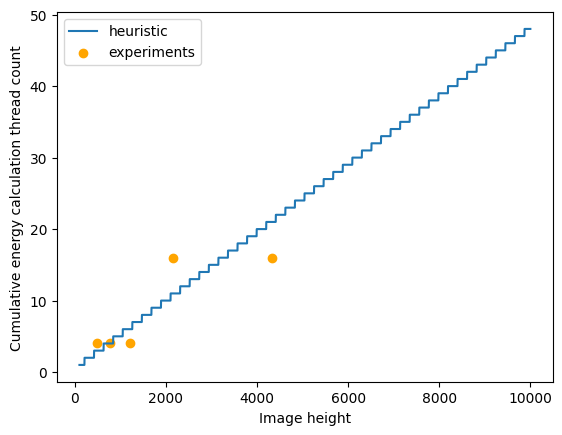

In [122]:
x = np.arange(100, 10000, 1)
y = (x/210 + 1).astype(np.int32)

x1 = larg[["h"]].to_numpy()
y1 = larg[["t_cum"]].to_numpy()

plt.plot(x, y, label="heuristic")
plt.scatter(x1,y1, label="experiments", c='orange')
plt.xlabel("Image height")
plt.ylabel("Cumulative energy calculation thread count")
plt.legend()
plt.plot()

In [108]:
print(larg[["h", "t_cum"]].to_csv(index=False))

h,t_cum
480,4
768,4
1200,4
2160,16
4320,16



In [84]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = larg[["h"]]
y = larg[["t_cum"]]
# Create linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict on test set
y_pred = model.predict(X)

# Evaluate
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# Optional: predict new value
new_X = pd.DataFrame([[1000]], columns=["h"])
predicted_time = model.predict(new_X)
print("Predicted t_energy, t_cum:", predicted_time[0])

Coefficients: [[0.00361852]]
Intercept: [2.33877902]
Mean Squared Error: 9.298710232158212
R^2 Score: 0.7309400974491258
Predicted t_energy, t_cum: [5.95729435]


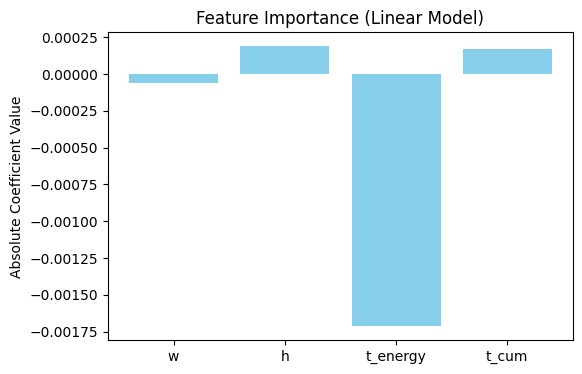

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature names
features = ["w", "h", "t_energy", "t_cum"]

# Importance = absolute value of coefficients
importance = model.coef_

# Create bar plot
plt.figure(figsize=(6,4))
plt.bar(features, importance, color="skyblue")
plt.title("Feature Importance (Linear Model)")
plt.ylabel("Absolute Coefficient Value")
plt.show()

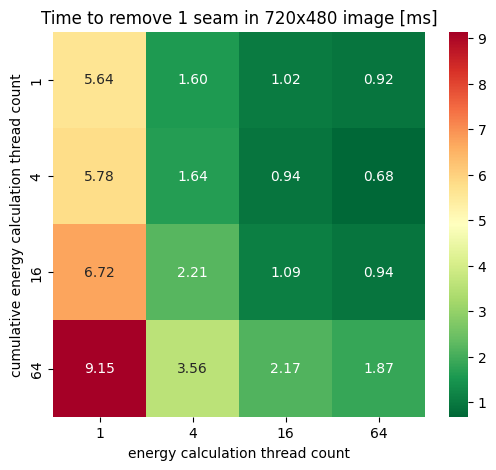

\begin{tabular}{lrrrr}
\toprule
t_energy & 1 & 4 & 16 & 64 \\
t_cum &  &  &  &  \\
\midrule
1 & 0.005637 & 0.001596 & 0.001024 & 0.000917 \\
4 & 0.005783 & 0.001645 & 0.000941 & 0.000684 \\
16 & 0.006720 & 0.002208 & 0.001093 & 0.000945 \\
64 & 0.009146 & 0.003565 & 0.002170 & 0.001865 \\
\bottomrule
\end{tabular}



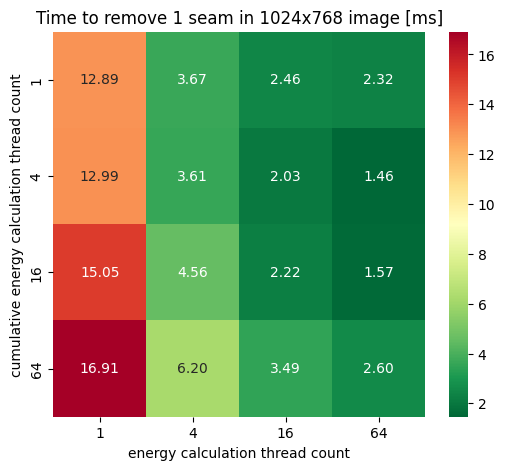

\begin{tabular}{lrrrr}
\toprule
t_energy & 1 & 4 & 16 & 64 \\
t_cum &  &  &  &  \\
\midrule
1 & 0.012889 & 0.003675 & 0.002463 & 0.002319 \\
4 & 0.012989 & 0.003607 & 0.002031 & 0.001464 \\
16 & 0.015046 & 0.004556 & 0.002218 & 0.001575 \\
64 & 0.016914 & 0.006203 & 0.003488 & 0.002599 \\
\bottomrule
\end{tabular}



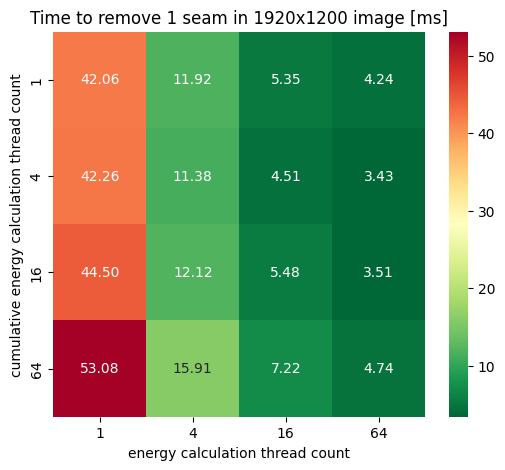

\begin{tabular}{lrrrr}
\toprule
t_energy & 1 & 4 & 16 & 64 \\
t_cum &  &  &  &  \\
\midrule
1 & 0.042056 & 0.011918 & 0.005355 & 0.004242 \\
4 & 0.042258 & 0.011378 & 0.004510 & 0.003435 \\
16 & 0.044501 & 0.012120 & 0.005481 & 0.003511 \\
64 & 0.053079 & 0.015912 & 0.007216 & 0.004736 \\
\bottomrule
\end{tabular}



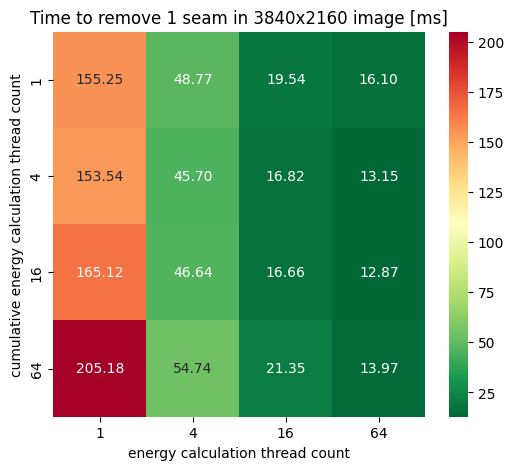

\begin{tabular}{lrrrr}
\toprule
t_energy & 1 & 4 & 16 & 64 \\
t_cum &  &  &  &  \\
\midrule
1 & 0.155248 & 0.048768 & 0.019541 & 0.016103 \\
4 & 0.153544 & 0.045696 & 0.016819 & 0.013149 \\
16 & 0.165125 & 0.046638 & 0.016663 & 0.012867 \\
64 & 0.205181 & 0.054738 & 0.021346 & 0.013967 \\
\bottomrule
\end{tabular}



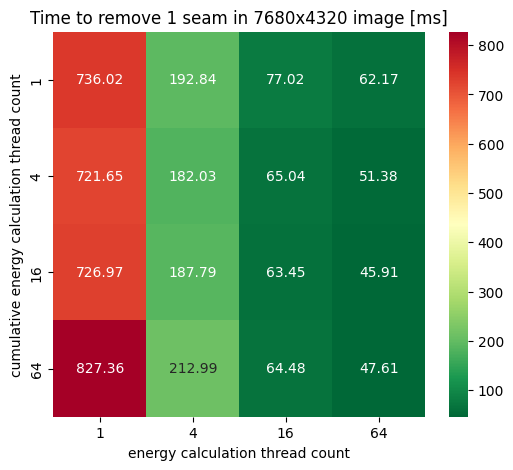

\begin{tabular}{lrrrr}
\toprule
t_energy & 1 & 4 & 16 & 64 \\
t_cum &  &  &  &  \\
\midrule
1 & 0.736022 & 0.192842 & 0.077017 & 0.062173 \\
4 & 0.721648 & 0.182028 & 0.065042 & 0.051376 \\
16 & 0.726966 & 0.187785 & 0.063448 & 0.045906 \\
64 & 0.827364 & 0.212991 & 0.064477 & 0.047607 \\
\bottomrule
\end{tabular}



In [73]:


sizes = agg[["w", "h"]].drop_duplicates()
for i in range(len(sizes)):
    example_w, example_h = sizes.iloc[i][["w", "h"]]

    img_agg = agg[(agg["w"] == example_w) & (agg["h"] == example_h)]

    pivot = img_agg.pivot_table(
        index="t_cum", columns="t_energy", values="total_time", aggfunc="mean"
    )

    # Plot heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(pivot*1000, annot=True, fmt=".2f", cmap="RdYlGn_r")
    plt.title(f"Time to remove 1 seam in {int(example_w)}x{int(example_h)} image [ms]")
    plt.xlabel("energy calculation thread count")
    plt.ylabel("cumulative energy calculation thread count")
    plt.show()

    print(pivot.to_latex())